In [67]:
# Import the necessary packages for the whole script
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal, Independent, TransformedDistribution
from torch.distributions.transforms import TanhTransform
import gymnasium as gym
import mujoco
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import numpy as np
import math
import random
import matplotlib.pyplot as plt
import minari
from torch.utils.data import Dataset, DataLoader
import wandb
import os
from matplotlib.patches import Ellipse
import re
import time

from skill_model import SkillPolicy, SkillPosterior, SkillPrior, TAWM
from utils import pack_state_from_obs, read_antmaze_obs, load_checkpoint


device = "cuda" if torch.cuda.is_available() else "cpu"

NUM_NEURONS = 256
Z_DIM = 256
# B, the number of subtrajectories per batch 
B = 100
# T, the length of each subtrajectory
T = 40
# AntMaze state and action dims
state_dim = 29
action_dim = 8

q_phi = SkillPosterior(state_dim=state_dim, action_dim=action_dim).to(device)
pi_theta = SkillPolicy(state_dim=state_dim, action_dim=action_dim).to(device)
p_psi = TAWM(state_dim=state_dim).to(device)
p_omega = SkillPrior(state_dim=state_dim).to(device)

ant_maze_dataset = minari.load_dataset('D4RL/antmaze/medium-diverse-v1')


In [68]:
def make_episode_splits(minari_dataset, train=0.8, val=0.1, test=0.1, seed=0):
    """Return three lists of episode indices (train_ids, val_ids, test_ids)."""
    episodes = list(minari_dataset.iterate_episodes())
    n = len(episodes)
    idxs = list(range(n))
    rng = np.random.RandomState(seed)
    rng.shuffle(idxs)
    n_train = int(round(train * n))
    n_val   = int(round(val * n))
    train_ids = idxs[:n_train]
    val_ids   = idxs[n_train:n_train+n_val]
    test_ids  = idxs[n_train+n_val:]
    return train_ids, val_ids, test_ids

def collate(batch):
    return {
        "s0": torch.stack([b["s0"] for b in batch], 0),
        "state_sequence": torch.stack([b["state_sequence"] for b in batch], 0),
        "action_sequence": torch.stack([b["action_sequence"] for b in batch], 0),
        "sT": torch.stack([b["sT"] for b in batch], 0),
    }

class SubtrajDataset(Dataset):
    """
    Loops over minari_dataset.iterate_episodes(), but keeps only episodes whose index is in episode_ids
    """
    def __init__(self, minari_dataset, T, episode_ids, stride=3):
        self.T = T
        self.items = [] 
        self.removed_items = [] 

        # Iterate all episodes but only process those whose global index is in episode_ids
        for ep_idx, ep in enumerate(minari_dataset.iterate_episodes()):
            if ep_idx not in set(episode_ids):
                continue
            obs = ep.observations["observation"]          
            ach = ep.observations["achieved_goal"]        
            act = ep.actions                               
            Ltot = len(obs)
            if Ltot < T + 1:
                continue

            state_ext = np.concatenate([obs, ach], axis=-1).astype(np.float32)
            for t in range(0, Ltot - T, stride):
                state_seq = state_ext[t:t+T]         
                s0 = state_seq[0]             
                action_seq = act[t:t+T].astype(np.float32)  
                sT = state_ext[t+T]           
                if np.linalg.norm(s0[-2:] - sT[-2:]) > 0.4:
                    self.items.append((s0, state_seq, action_seq, sT))
                else:
                    self.removed_items.append((s0, state_seq, action_seq, sT))

    def __len__(self): 
        return len(self.items)

    def __getitem__(self, i):
        """standardize s0, state_sequence, and sT by (x - mean) / std"""
        
        s0, S, A, sT = self.items[i]
        if hasattr(self, "stats") and self.stats is not None:
            S_mean, S_std = self.stats
            S  = (S  - S_mean) / S_std
            s0 = (s0 - S_mean) / S_std
            sT = (sT - S_mean) / S_std
            A  = A
        return {
            "s0": torch.as_tensor(s0, dtype=torch.float32),
            "state_sequence": torch.as_tensor(S, dtype=torch.float32),
            "action_sequence": torch.as_tensor(A, dtype=torch.float32),
            "sT": torch.as_tensor(sT, dtype=torch.float32),
        }

train_ids, val_ids, test_ids = make_episode_splits(
    ant_maze_dataset, train=0.8, val=0.0, test=0.2, seed=0
)
print(f"train episodes:{len(train_ids)}  val episodes:{len(val_ids)}  test episodes:{len(test_ids)}")

train_ds = SubtrajDataset(ant_maze_dataset, T=T, episode_ids=train_ids, stride=3)
val_ds = SubtrajDataset(ant_maze_dataset, T=T, episode_ids=val_ids,   stride=3)
test_ds = SubtrajDataset(ant_maze_dataset, T=T, episode_ids=test_ids,  stride=3)

print(f"train subtrajs:{len(train_ds)}  val subtrajs:{len(val_ds)}  test subtrajs:{len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=B, shuffle=True,  collate_fn=collate, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=B, shuffle=False, collate_fn=collate, drop_last=False)
test_loader  = DataLoader(test_ds, batch_size=B, shuffle=False, collate_fn=collate, drop_last=False)

train episodes:800  val episodes:0  test episodes:200
train subtrajs:110974  val subtrajs:0  test subtrajs:26211


In [82]:
def to_torch(x):
    return torch.as_tensor(x, dtype=torch.float32, device=device)

def recover_ant_env():
    return ant_maze_dataset.recover_environment()

def set_env_state(env, qpos, qvel):
    """Write qpos/qvel into MuJoCo and forward."""
    _, model, data = get_sim_handles(env)
    # Set the physical state
    data.qpos[:] = qpos
    data.qvel[:] = qvel
    # Required step after makeing a manual state change
    mujoco.mj_forward(model, data)

def policy_dist(mu, std):
    # build a tanh-squashed normal action dist
    base = Independent(Normal(mu, std.clamp_min(0.05)), 1) # clamps std to be at least 0.05 to prevent exploding/vanishing gradients
    return TransformedDistribution(base, [TanhTransform(cache_size=1)]) # Creates a Independent Normal over action dims applied Tanh Transform to map actions to (-1, 1)

def get_sim_handles(env):
    """Unwraps Gym wrappers to access MuJoCo model and data to work with qpos/qvel and forward dynamics. 
    Return (unwrapped MuJoCo environment, MuJoCo model, muJoCo data)"""
    t = env
    for attr in ["env", "unwrapped"]: # for the current env, replace env with env.env and then find env.env.unwrapped
        if hasattr(t, attr):
            t = getattr(t, attr)
    # t should now be the innermost env and grab the MuJoCo data and model
    # sim = getattr(t, "sim", None)
    # if sim is not None and hasattr(sim, "model") and hasattr(sim, "data"):
    #     return t, sim.model, sim.data
    
    # CHECK THIS
    if hasattr(t, "model") and hasattr(t, "data"):
        return t, t.model, t.data
    
def split_obs_to_qpos_qvel(s0_obs, s0_ag, env):
    """Split dataset obs into qpos and qvel to reset physics. Need to provide exact qpos and qvel to reset dataset state"""
    _, model, data = get_sim_handles(env)
    nq, nv = int(model.nq), int(model.nv)  

    s0_obs = np.asarray(s0_obs, np.float32).ravel()
    s0_ag  = np.asarray(s0_ag,  np.float32).ravel()

    qpos = data.qpos.ravel().copy()
    qvel = data.qvel.ravel().copy()

    # fill exact slices
    qpos[0:2] = s0_ag
    qpos[2:nq] = s0_obs[:(nq - 2)]
    qvel[:nv] = s0_obs[(nq - 2):(nq - 2 + nv)]

    return qpos.astype(np.float32), qvel.astype(np.float32)


def _get_start_xy_from_item(item):
    s0, S, A, sT = item
    return s0[-2:].astype(np.float32)


def find_subtrajs_starting_near(ds, ref_idx, radius=0.25):
    """
    Returns near_idxs: list of indices i where ||start_xy(i) - start_xy(ref)|| <= radius and np.array of distances aligned with near_idxs
    """
    ref_item = ds.items[ref_idx]
    ref_xy = _get_start_xy_from_item(ref_item)

    near_idxs = []
    near_dists = []

    # scan all subtrajectories
    for i, item in enumerate(ds.items):
        xy = _get_start_xy_from_item(item)
        d = np.linalg.norm(xy - ref_xy)
        if d <= radius:
            near_idxs.append(i)
            near_dists.append(d)

    # sort by distance (closest first)
    order = np.argsort(near_dists)
    near_idxs = [near_idxs[j] for j in order]
    near_dists = np.asarray([near_dists[j] for j in order], dtype=np.float32)
    return ref_xy, near_idxs, near_dists


def plot_nearby_subtrajectory(
    ds,
    ref_idx,
    radius=0.25,
    max_plots=2,
    overlay_reference=True,
    linewidth=2.0,
    alpha=0.35,
    title=None,
):
    ref_xy, near_idxs, near_dists = find_subtrajs_starting_near(
        ds, ref_idx, radius=radius
    )

    if len(near_idxs) == 0:
        print("No nearby subtrajectories found.")
        return None

    # limit how many to plot
    plot_idx = near_idxs[:max_plots]

    fig, ax = plt.subplots(figsize=(7.0, 6.5))

    # plot nearby subtrajectories
    for i in plot_idx:
        s0, S, A, sT = ds.items[i]
        xy = S[:, -2:]

        ax.plot(xy[:, 0], xy[:, 1], lw=linewidth, alpha=alpha)

        # start marker
        ax.scatter(xy[0, 0], xy[0, 1], s=20, alpha=0.9)

    # mark the reference start
    ax.scatter(ref_xy[0], ref_xy[1], s=120, marker="X", color="k", zorder=5, label="ref start")

    # optionally overlay the reference trajectory itself
    if overlay_reference:
        s0, S, A, sT = ds.items[ref_idx]
        ref_traj = S[:, -2:]

        ax.plot(ref_traj[:, 0], ref_traj[:, 1], "k--", lw=3.0, alpha=0.95, label="ref subtraj")
        ax.scatter(ref_traj[0, 0], ref_traj[0, 1], s=80, marker="s", color="k", zorder=6)
        ax.scatter(ref_traj[-1, 0], ref_traj[-1, 1], s=90, marker="*", color="k", zorder=6)

    ax.set_aspect("equal", "box")
    
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if title is None:
        title = f"Subtrajectories starting within r={radius} of idx={ref_idx} (found {len(near_idxs)})"
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return plot_idx


def rollout_xy_trajectories(
    env,
    s0_obs_ds,
    s0_ag_ds=None,
    N_trajs=3,
    horizon=T,
    seed=0,
    resample_skill_per_traj=True,
    use_prior=True,
    z_fixed=None,
):
    """
    Reset env to dataset start (s0_obs_ds, s0_ag_ds), choose skill z,
    roll out pi_theta(a|s,z) for H steps.
    """
    H = horizon
    np.random.seed(seed)
    torch.manual_seed(seed)

    # MuJoCo state for this dataset s0
    s0_qpos, s0_qvel = split_obs_to_qpos_qvel(s0_obs_ds, s0_ag_ds, env)

    trajs_xy, zs_used = [], []

    # Precompute z if we want same skill for all trajectories
    z_global = None
    if not resample_skill_per_traj:
        env.reset()
        set_env_state(env, s0_qpos, s0_qvel)
        obs = read_antmaze_obs(env)
        _, _, s0_env = pack_state_from_obs(obs)
        s0_t = to_torch(s0_env).unsqueeze(0)

        if z_fixed is not None:
            z_global = z_fixed.to(device).detach().clone()
        elif use_prior:
            mu_pr, std_pr = p_omega(s0_t)
            z_global = (mu_pr + std_pr * torch.randn_like(mu_pr)).squeeze(0)

    for k in range(N_trajs):
        env.reset()
        set_env_state(env, s0_qpos, s0_qvel)

        obs = read_antmaze_obs(env)
        _, ag0, s0_env = pack_state_from_obs(obs)
        s0_t = to_torch(s0_env).unsqueeze(0)

        if resample_skill_per_traj:
            if z_fixed is not None:
                z = z_fixed.to(device).detach().clone()
            elif use_prior:
                mu_pr, std_pr = p_omega(s0_t)
                z = (mu_pr + std_pr * torch.randn_like(mu_pr)).squeeze(0)
            else:
                raise ValueError("If use_prior=False and z_fixed is None, no skill source.")
        else:
            z = z_global

        zs_used.append(z.detach().cpu())

        xy = [ag0.copy()]
        cur_obs = obs
        pi_theta.eval()
        for t in range(H):
            _, _, st = pack_state_from_obs(cur_obs)
            st_t = to_torch(st).unsqueeze(0)
            a_mu, a_std = pi_theta(st_t, z.unsqueeze(0).to(device))
            a_dist = policy_dist(a_mu, a_std)
            a = a_dist.sample().squeeze(0).cpu().numpy().astype(np.float32)

            cur_obs, _, term, trunc, _ = env.step(a)
            _, ag_t, _ = pack_state_from_obs(cur_obs)
            xy.append(ag_t.copy())
            if term or trunc:
                break

        trajs_xy.append(np.stack(xy, axis=0))

    return trajs_xy, zs_used, s0_env

@torch.no_grad()
def sample_skill_from_posterior(S_seq, A_seq):
    mu_z, std_z = q_phi(S_seq, A_seq)
    z = mu_z + std_z * torch.randn_like(mu_z)   
    return z.squeeze(0)      


def plot_xy_trajectories(trajs_xy, title="", s0_env=None, z=None, demo_xy=None, save=False, stem="traj_detail", meta=None):
    """
    Plot each rollout trajectory as a line with start circle, end star.
    If s0_env and z are given, overlay TAWM ellipses and mean.
    If demo_xy is given, overlay the dataset subtrajectory used for the posterior.
    """
    fig, ax = plt.subplots(figsize=(6.8, 6))
    colors = cm.get_cmap("viridis", len(trajs_xy))

    all_xy = np.concatenate(trajs_xy, axis=0)

    # rollout posterior trajectories
    for i, xy in enumerate(trajs_xy):
        # c = colors_post(i)
        ax.plot(xy[:, 0], xy[:, 1], "-", lw=1.5, alpha=0.9, color="blue", label=f"post traj {i}")
        ax.scatter(xy[0, 0],  xy[0, 1],  s=40, marker="o", color="blue", edgecolor="k", zorder=3)
        ax.scatter(xy[-1,0], xy[-1,1], s=70, marker="*", color="blue", edgecolor="k", zorder=3)
        # tcolors = np.linspace(0, 1, len(xy))
        # ax.scatter(xy[:,0], xy[:,1], c=tcolors, cmap="viridis", s=14, alpha=0.8)

    # rollout prior trajectories
    for i, xy in enumerate(trajs_xy):
        # c = colors_prior(i)
        ax.plot(xy[:, 0], xy[:, 1], "-", lw=1.5, alpha=0.9, color="red", label=f"prior traj {i}")
        ax.scatter(xy[0, 0],  xy[0, 1],  s=40, marker="o", color="red", edgecolor="k", zorder=3)
        ax.scatter(xy[-1,0], xy[-1,1], s=70, marker="*", color="red", edgecolor="k", zorder=3)
        # tcolors = np.linspace(0, 1, len(xy))
        # ax.scatter(xy[:,0], xy[:,1], c=tcolors, cmap="magma", s=14, alpha=0.8)

    # overlay dataset subtrajectory used for posterior
    if demo_xy is not None:
        # thick black dashed line for the dataset subtrajectory
        ax.plot(
            demo_xy[:, 0], demo_xy[:, 1],
            "k--", lw=3, alpha=0.9, label="dataset subtrajectory"
        )
        # mark its start and end
        ax.scatter(demo_xy[0, 0], demo_xy[0, 1],
                   s=80, marker="s", c="k", edgecolor="w", zorder=5)
        ax.scatter(demo_xy[-1, 0], demo_xy[-1, 1],
                   s=90, marker="*", c="k", edgecolor="w", zorder=5)

        # include in bounds
        all_xy = np.vstack([all_xy, demo_xy])

    # TAWM ellipses
    if (s0_env is not None) and (z is not None):
        mean_xy, cov_xy = tawm_xy_gaussian(s0_env, z)

        draw_cov_ellipse(ax, mean_xy, cov_xy, n_std=1.0,
                         edgecolor="darkorange", linewidth=2)
        draw_cov_ellipse(ax, mean_xy, cov_xy, n_std=2.0,
                         edgecolor="orange", linestyle="--", linewidth=1.5)

        ax.scatter([mean_xy[0]], [mean_xy[1]],
                   c="darkorange", s=60, marker="X", zorder=4)

        eigvals = np.linalg.eigvalsh(cov_xy)
        max_std = np.sqrt(eigvals.max())
        r = 2.0 * max_std
        all_xy = np.vstack([
            all_xy,
            mean_xy[None, :],
            mean_xy[None, :] + [r, r],
            mean_xy[None, :] - [r, r],
        ])

    lo = all_xy.min(axis=0)
    hi = all_xy.max(axis=0)
    pad = 0.05 * (hi - lo + 1e-9)
    ax.set_xlim(lo[0] - pad[0], hi[0] + pad[0])
    ax.set_ylim(lo[1] - pad[1], hi[1] + pad[1])

    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    # ax.legend()
    plt.tight_layout()
    path = None
    plt.show()
    

@torch.no_grad()
def tawm_xy_gaussian(s0_env, z):
    """
    Get mean and 2x2 covariance of TAWM's terminal XY
    """
    s0_t = to_torch(s0_env).unsqueeze(0)  
    z_t  = z.unsqueeze(0).to(device)      
    mu_T, std_T = p_psi(s0_t, z_t)      
    mu_T  = mu_T.squeeze(0).cpu().numpy()
    std_T = std_T.squeeze(0).cpu().numpy()

    mean_xy = mu_T[-2:]
    std_xy  = std_T[-2:]
    cov_xy  = np.diag(std_xy**2)
    return mean_xy, cov_xy

def draw_cov_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellip = Ellipse(xy=mean, width=width, height=height, angle=theta, fill=False, **kwargs)
    ax.add_patch(ellip)

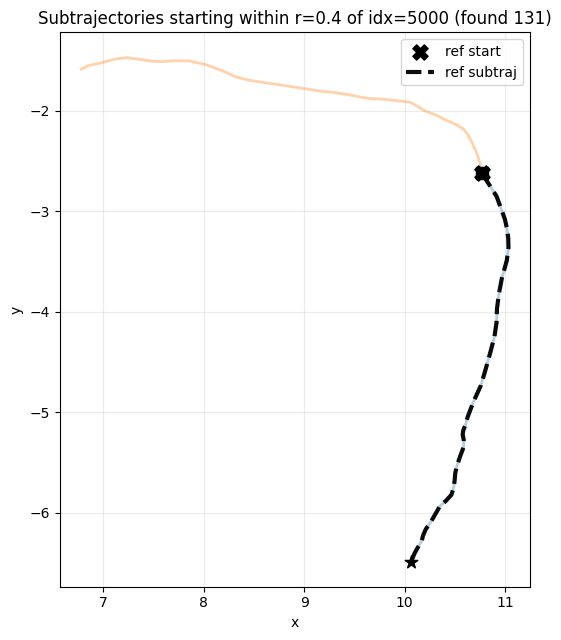

[5000, 70900]


In [102]:
idx = plot_nearby_subtrajectory(train_ds, ref_idx=5000, radius=0.4, max_plots=2)
print(idx)

[checkpoint] loaded <- ../checkpoints/kl_balancing/antmaze_diverse_detached_klbalance_epoch75_beta1.0_gamma0.001.pth


/var/folders/wp/q7yyy4ls2m3bvyscgh359t0r0000gn/T/ipykernel_4853/756121956.py:241: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("viridis", len(trajs_xy))


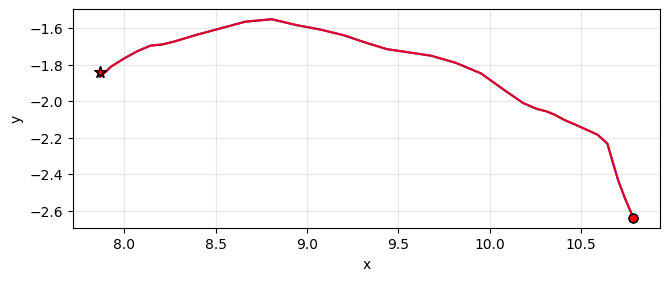

tensor([-6.9546], grad_fn=<SumBackward1>)
[0.00095427]


In [103]:
env = recover_ant_env()
ckpt_path = "../checkpoints/kl_balancing/antmaze_diverse_detached_klbalance_epoch75_beta1.0_gamma0.001.pth"
load_checkpoint(ckpt_path, q_phi, pi_theta, p_psi, p_omega, strict=True)
q_phi.eval(); pi_theta.eval(); p_omega.eval(); p_psi.eval()

s0, S, A, sT = train_ds.items[idx[1]]
S_seq = train_ds[idx[1]]["state_sequence"].unsqueeze(0).to(device)
A_seq = train_ds[idx[1]]["action_sequence"].unsqueeze(0).to(device)

s0_obs = s0[:27]
s0_ag = s0[27:]

z = sample_skill_from_posterior(torch.as_tensor(S_seq, dtype=torch.float32), torch.as_tensor(A_seq, dtype=torch.float32))
post_traj, _, s0_env = rollout_xy_trajectories(env, s0_obs, s0_ag, N_trajs=1, horizon=T, seed=0, resample_skill_per_traj=False, use_prior=False, z_fixed=z)

plot_xy_trajectories(post_traj)

s0_t = to_torch(s0_env).unsqueeze(0)
mu_pr, std_pr = p_omega(s0_t)

dist = Independent(Normal(mu_pr, std_pr), 1)
print(dist.log_prob(z))
print(np.exp(dist.log_prob(z).detach().numpy()))

/var/folders/wp/q7yyy4ls2m3bvyscgh359t0r0000gn/T/ipykernel_4853/756121956.py:241: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("viridis", len(trajs_xy))


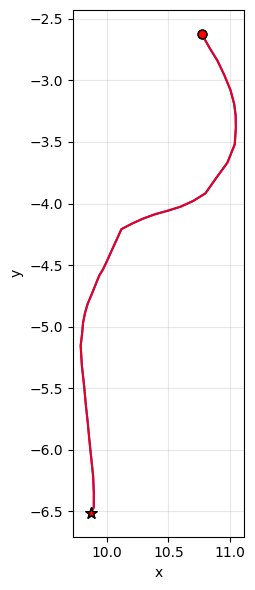

tensor([-103.7496], grad_fn=<SumBackward1>)
[1.e-45]


In [104]:
s0, S, A, sT = train_ds.items[idx[0]]
S_seq = train_ds[idx[0]]["state_sequence"].unsqueeze(0).to(device)
A_seq = train_ds[idx[0]]["action_sequence"].unsqueeze(0).to(device)

s0_obs = s0[:27]
s0_ag = s0[27:]

z = sample_skill_from_posterior(torch.as_tensor(S_seq, dtype=torch.float32), torch.as_tensor(A_seq, dtype=torch.float32))
post_traj, _, s0_env = rollout_xy_trajectories(env, s0_obs, s0_ag, N_trajs=1, horizon=T, seed=0, resample_skill_per_traj=False, use_prior=False, z_fixed=z)

plot_xy_trajectories(post_traj)

s0_t = to_torch(s0_env).unsqueeze(0)
mu_pr, std_pr = p_omega(s0_t)

dist = Independent(Normal(mu_pr, std_pr), 1)
print(dist.log_prob(z))
print(np.exp(dist.log_prob(z).detach().numpy()))

/var/folders/wp/q7yyy4ls2m3bvyscgh359t0r0000gn/T/ipykernel_4853/756121956.py:241: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("viridis", len(trajs_xy))


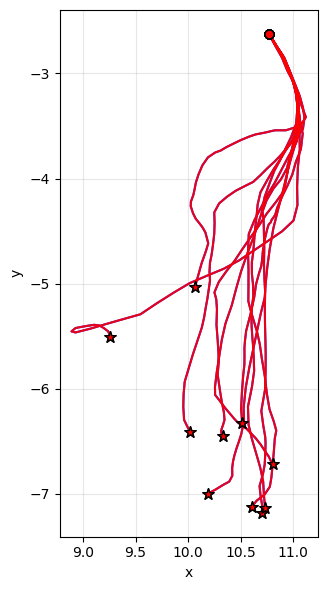

In [105]:

prior_trajs_xy, _, s0_env = rollout_xy_trajectories(
        env,
        s0_obs,
        s0_ag,
        N_trajs=10,
        horizon=T,
        seed=0,
        resample_skill_per_traj=True,
        use_prior=True,    
        z_fixed=None,
)
plot_xy_trajectories(prior_trajs_xy)
